# UPI Transaction Forecasting
 

This notebook follow the pipeline to analyze and forecast UPI (Unified Payments Interface) transaction volume and value using classical time-series models (ARIMA, SARIMA) and machine-learning models (Random Forest, XGBoost).

**Dataset:** `upi_forecasting_dataset.csv` — monthly digital-payments data for India (UPI, IMPS, NEFT, RTGS, Mobile/Internet Payments, AePS, PPI Wallets, etc.)


# Data Collection

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

RAW_PATH = 'upi_forecasting_dataset.csv'
raw_df = pd.read_csv(RAW_PATH)

print('Shape:', raw_df.shape)


Shape: (79, 21)


In [3]:
raw_df.head()

,Date,Month_Year,UPI_Volume_Lakh,UPI_Value_RsCr,IMPS_Volume_Lakh,IMPS_Value_RsCr,NEFT_Volume_Lakh,NEFT_Value_RsCr,RTGS_Volume_Lakh,RTGS_Value_RsCr,MobilePayments_Volume_Lakh,MobilePayments_Value_RsCr,InternetPayments_Volume_Lakh,InternetPayments_Value_RsCr,AePS_Volume_Lakh,AePS_Value_RsCr,PPI_Wallet_Volume_Lakh,PPI_Wallet_Value_RsCr,Num_UPI_QR_Lakh,Num_PoS_Terminals_Lakh,Num_Cards_Lakh
0,2019-11-01,Nov-2019,12187.70742,189229.089108,2280.75192,202903.641817,2194.59398,1.734651e+06,133.87410,8.679806e+06,13534.23286,471295.319916,2951.47401,4.404301e+06,0.63999,33.097328,3354.07961,14652.425084,NaN,41.28351,8851.69355
1,2019-12-01,Dec-2019,13084.01713,202520.758566,2564.67272,210934.233542,2336.88014,1.942231e+06,136.01582,1.031694e+07,14322.15018,493342.155860,2994.23178,5.534795e+06,0.84412,35.363818,3652.64098,15834.653406,NaN,42.48777,8606.57053
2,2020-01-01,Jan-2020,13050.19232,216242.974143,2595.25523,216810.700327,2605.55245,1.929464e+06,137.28613,9.880821e+06,14402.69650,521367.839684,3023.77660,5.570802e+06,0.75583,36.620500,3876.23037,15408.205667,NaN,42.91612,8725.30245
3,2020-02-01,Feb-2020,13256.93237,222516.950030,2477.97744,214565.657115,2483.57357,1.870494e+06,133.15318,8.990097e+06,14284.27783,525845.173765,3128.46229,4.854804e+06,0.74143,39.798793,3782.81666,14460.610638,NaN,43.70702,8801.81043
4,2020-03-01,Mar-2020,12468.44550,206462.307026,2168.23055,201961.704278,2623.69785,2.283665e+06,118.94618,1.204722e+07,13830.33455,520199.111814,2807.66678,6.177461e+06,0.66389,36.202426,3178.59822,13111.486866,NaN,44.33973,8863.06744


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          79 non-null     object 
 1   Month_Year                    79 non-null     object 
 2   UPI_Volume_Lakh               79 non-null     float64
 3   UPI_Value_RsCr                79 non-null     float64
 4   IMPS_Volume_Lakh              79 non-null     float64
 5   IMPS_Value_RsCr               79 non-null     float64
 6   NEFT_Volume_Lakh              79 non-null     float64
 7   NEFT_Value_RsCr               79 non-null     float64
 8   RTGS_Volume_Lakh              79 non-null     float64
 9   RTGS_Value_RsCr               79 non-null     float64
 10  MobilePayments_Volume_Lakh    79 non-null     float64
 11  MobilePayments_Value_RsCr     79 non-null     float64
 12  InternetPayments_Volume_Lakh  79 non-null     float64
 13  Interne

##  Data Cleaning

In [5]:
df = raw_df.copy()

# Parse the Date column and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.set_index('Date')

# Give the series an explicit monthly frequency
df = df.asfreq('MS')

print('Duplicate rows:', df.duplicated().sum())
print('\nMissing values per column:')
print(df.isna().sum()[df.isna().sum() > 0])

Duplicate rows: 0

Missing values per column:
Num_UPI_QR_Lakh    10
dtype: int64


In [6]:
df['Num_UPI_QR_Lakh'] = df['Num_UPI_QR_Lakh'].interpolate(method='linear').bfill()

# Sanity checks: no negative values in any numeric column
neg_counts = (df.select_dtypes(include=[np.number]) < 0).sum()
print('Columns with negative values:', neg_counts[neg_counts > 0].to_dict())

print('\nCleaned shape:', df.shape)
print('Date range:', df.index.min().date(), 'to', df.index.max().date())
df.head()

Columns with negative values: {}

Cleaned shape: (79, 20)
Date range: 2019-11-01 to 2026-05-01


,Month_Year,UPI_Volume_Lakh,UPI_Value_RsCr,IMPS_Volume_Lakh,IMPS_Value_RsCr,NEFT_Volume_Lakh,NEFT_Value_RsCr,RTGS_Volume_Lakh,RTGS_Value_RsCr,MobilePayments_Volume_Lakh,MobilePayments_Value_RsCr,InternetPayments_Volume_Lakh,InternetPayments_Value_RsCr,AePS_Volume_Lakh,AePS_Value_RsCr,PPI_Wallet_Volume_Lakh,PPI_Wallet_Value_RsCr,Num_UPI_QR_Lakh,Num_PoS_Terminals_Lakh,Num_Cards_Lakh
Date,,,,,,,,,,,,,,,,,,,,
2019-11-01,Nov-2019,12187.70742,189229.089108,2280.75192,202903.641817,2194.59398,1.734651e+06,133.87410,8.679806e+06,13534.23286,471295.319916,2951.47401,4.404301e+06,0.63999,33.097328,3354.07961,14652.425084,604.07061,41.28351,8851.69355
2019-12-01,Dec-2019,13084.01713,202520.758566,2564.67272,210934.233542,2336.88014,1.942231e+06,136.01582,1.031694e+07,14322.15018,493342.155860,2994.23178,5.534795e+06,0.84412,35.363818,3652.64098,15834.653406,604.07061,42.48777,8606.57053
2020-01-01,Jan-2020,13050.19232,216242.974143,2595.25523,216810.700327,2605.55245,1.929464e+06,137.28613,9.880821e+06,14402.69650,521367.839684,3023.77660,5.570802e+06,0.75583,36.620500,3876.23037,15408.205667,604.07061,42.91612,8725.30245
2020-02-01,Feb-2020,13256.93237,222516.950030,2477.97744,214565.657115,2483.57357,1.870494e+06,133.15318,8.990097e+06,14284.27783,525845.173765,3128.46229,4.854804e+06,0.74143,39.798793,3782.81666,14460.610638,604.07061,43.70702,8801.81043
2020-03-01,Mar-2020,12468.44550,206462.307026,2168.23055,201961.704278,2623.69785,2.283665e+06,118.94618,1.204722e+07,13830.33455,520199.111814,2807.66678,6.177461e+06,0.66389,36.202426,3178.59822,13111.486866,604.07061,44.33973,8863.06744


## UPI Extraction
 

In [7]:
upi = df[['UPI_Volume_Lakh', 'UPI_Value_RsCr']].copy()
upi['UPI_Avg_Ticket_Size_Rs'] = (upi['UPI_Value_RsCr'] * 1e7) / (upi['UPI_Volume_Lakh'] * 1e5)  # Rs per transaction

print(upi.shape)
upi.describe()

(79, 3)


,UPI_Volume_Lakh,UPI_Value_RsCr,UPI_Avg_Ticket_Size_Rs
count,79.000000,7.900000e+01,79.000000
mean,96527.468384,1.403040e+06,1588.771685
std,69367.601685,8.716551e+05,208.871743
min,9995.743760,1.511407e+05,1242.220307
25%,30265.089625,5.766282e+05,1390.798577
50%,80385.880000,1.299059e+06,1581.642323
75%,152618.840000,2.109740e+06,1783.849221
max,232019.280000,2.990424e+06,1958.478130


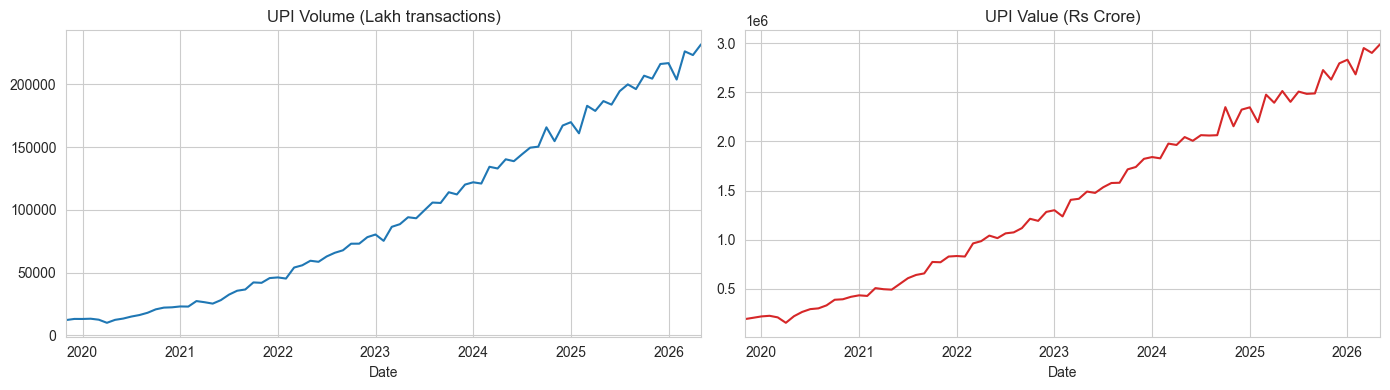

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
upi['UPI_Volume_Lakh'].plot(ax=ax[0], title='UPI Volume (Lakh transactions)', color='#1f77b4')
upi['UPI_Value_RsCr'].plot(ax=ax[1], title='UPI Value (Rs Crore)', color='#d62728')
plt.tight_layout()
plt.show()

## 04. Exploratory Data Analysis

In [9]:
upi.describe().T

,count,mean,std,min,25%,50%,75%,max
UPI_Volume_Lakh,79.0,9.652747e+04,69367.601685,9995.743760,30265.089625,8.038588e+04,1.526188e+05,2.320193e+05
UPI_Value_RsCr,79.0,1.403040e+06,871655.082148,151140.664272,576628.181102,1.299059e+06,2.109740e+06,2.990424e+06
UPI_Avg_Ticket_Size_Rs,79.0,1.588772e+03,208.871743,1242.220307,1390.798577,1.581642e+03,1.783849e+03,1.958478e+03


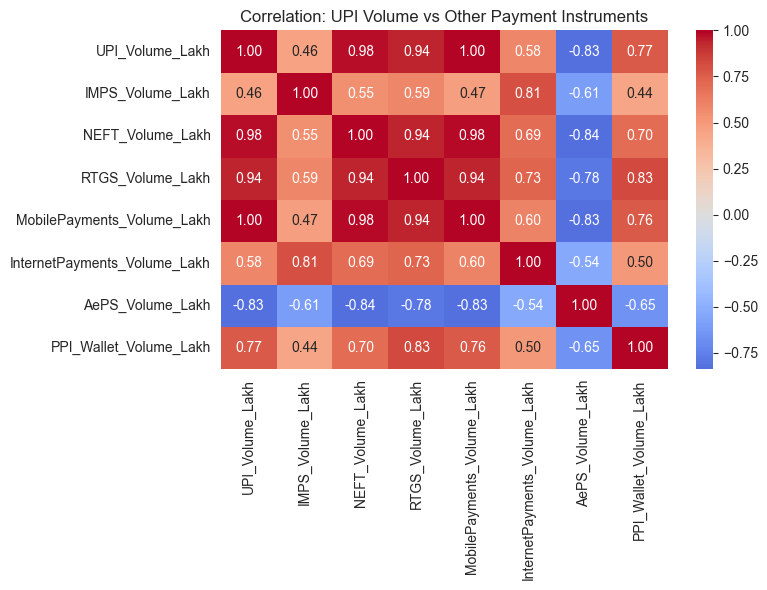

In [10]:
# Correlation of UPI volume with other digital payment instruments
compare_cols = ['UPI_Volume_Lakh', 'IMPS_Volume_Lakh', 'NEFT_Volume_Lakh', 'RTGS_Volume_Lakh',
                 'MobilePayments_Volume_Lakh', 'InternetPayments_Volume_Lakh', 'AePS_Volume_Lakh',
                 'PPI_Wallet_Volume_Lakh']
corr = df[compare_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: UPI Volume vs Other Payment Instruments')
plt.tight_layout()
plt.show()

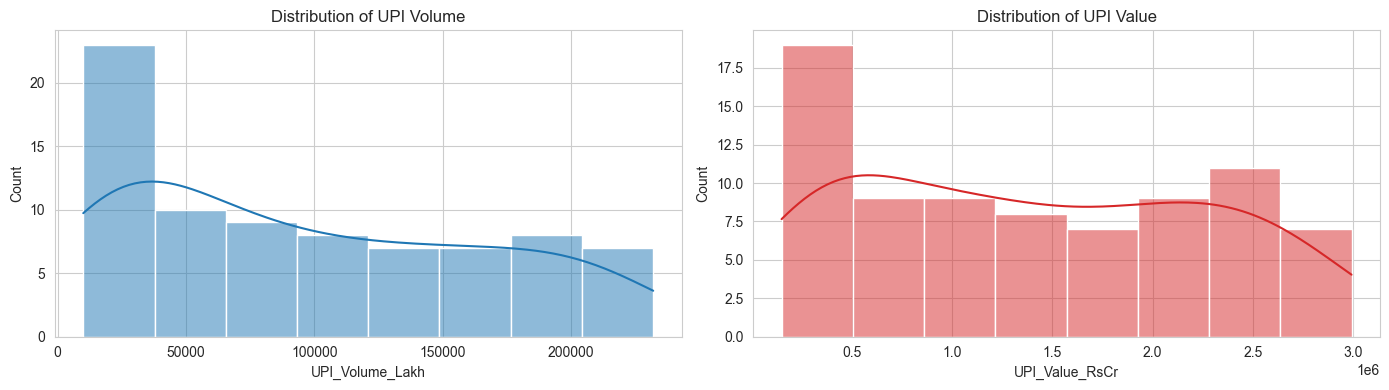

In [11]:
# Distribution of monthly volume & value
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(upi['UPI_Volume_Lakh'], kde=True, ax=ax[0], color='#1f77b4')
ax[0].set_title('Distribution of UPI Volume')
sns.histplot(upi['UPI_Value_RsCr'], kde=True, ax=ax[1], color='#d62728')
ax[1].set_title('Distribution of UPI Value')
plt.tight_layout()
plt.show()

## 05. Trend Analysis

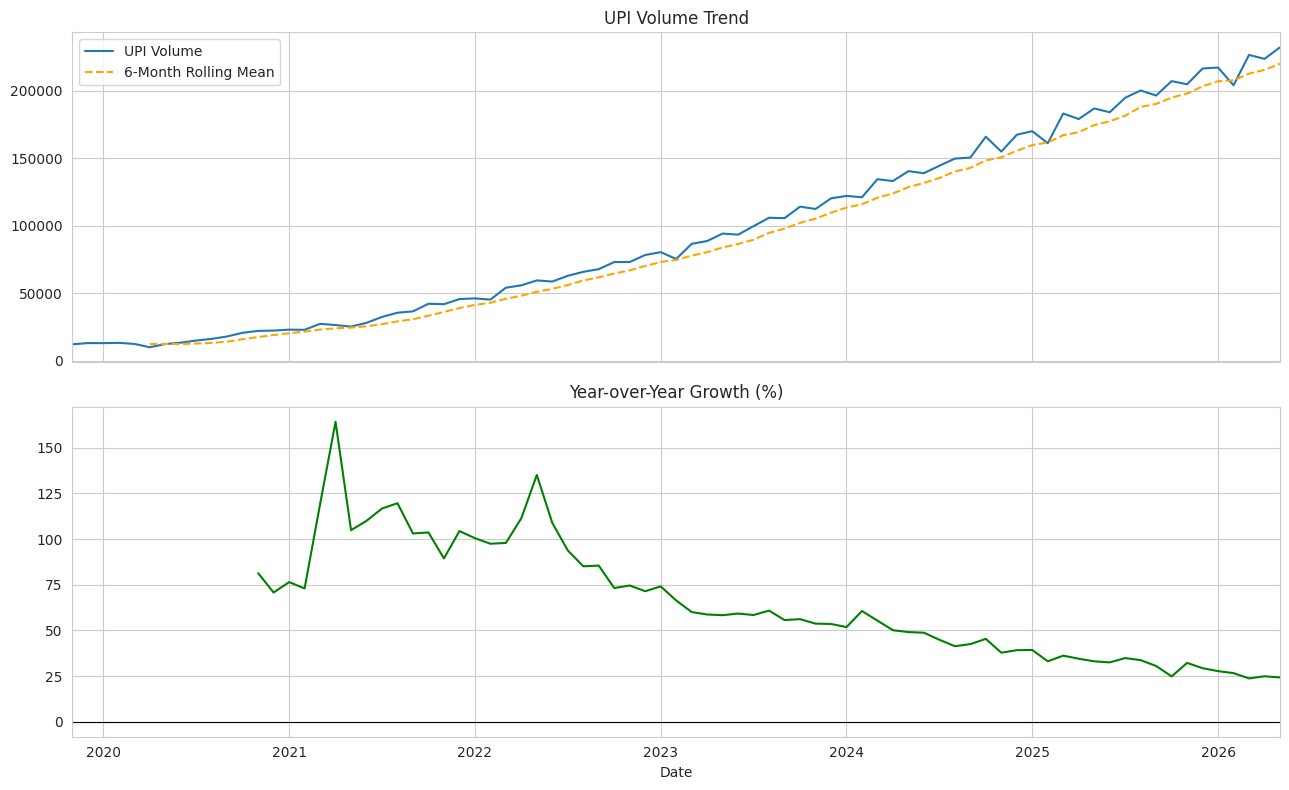

Average YoY growth: 65.29 %
Latest YoY growth: 24.22 %


In [10]:
upi['MoM_Growth_%'] = upi['UPI_Volume_Lakh'].pct_change() * 100
upi['YoY_Growth_%'] = upi['UPI_Volume_Lakh'].pct_change(12) * 100

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
upi['UPI_Volume_Lakh'].plot(ax=ax[0], label='UPI Volume', color='#1f77b4')
upi['UPI_Volume_Lakh'].rolling(6).mean().plot(ax=ax[0], label='6-Month Rolling Mean', color='orange', linestyle='--')
ax[0].set_title('UPI Volume Trend')
ax[0].legend()

upi['YoY_Growth_%'].plot(ax=ax[1], color='green')
ax[1].axhline(0, color='black', linewidth=0.8)
ax[1].set_title('Year-over-Year Growth (%)')
plt.tight_layout()
plt.show()

print('Average YoY growth:', round(upi['YoY_Growth_%'].mean(), 2), '%')
print('Latest YoY growth:', round(upi['YoY_Growth_%'].iloc[-1], 2), '%')

## 06. Seasonality Analysis

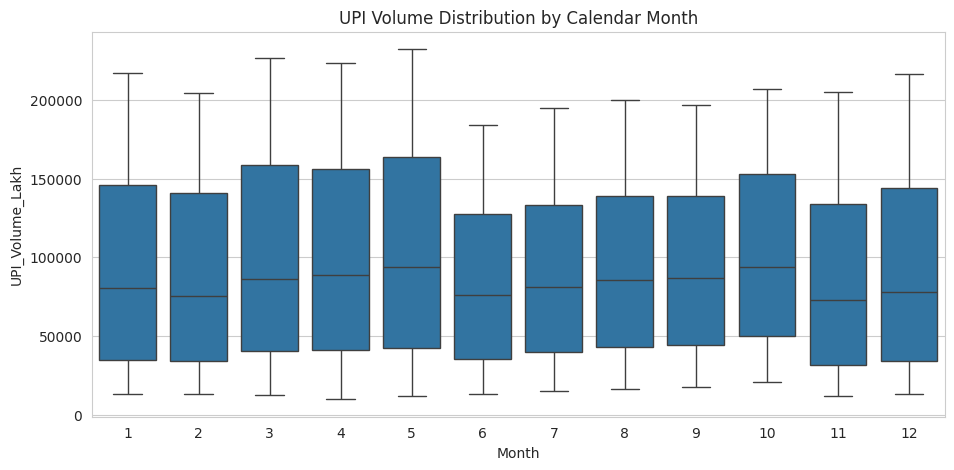

In [11]:
upi['Month'] = upi.index.month
plt.figure(figsize=(11, 5))
sns.boxplot(x='Month', y='UPI_Volume_Lakh', data=upi)
plt.title('UPI Volume Distribution by Calendar Month')
plt.show()

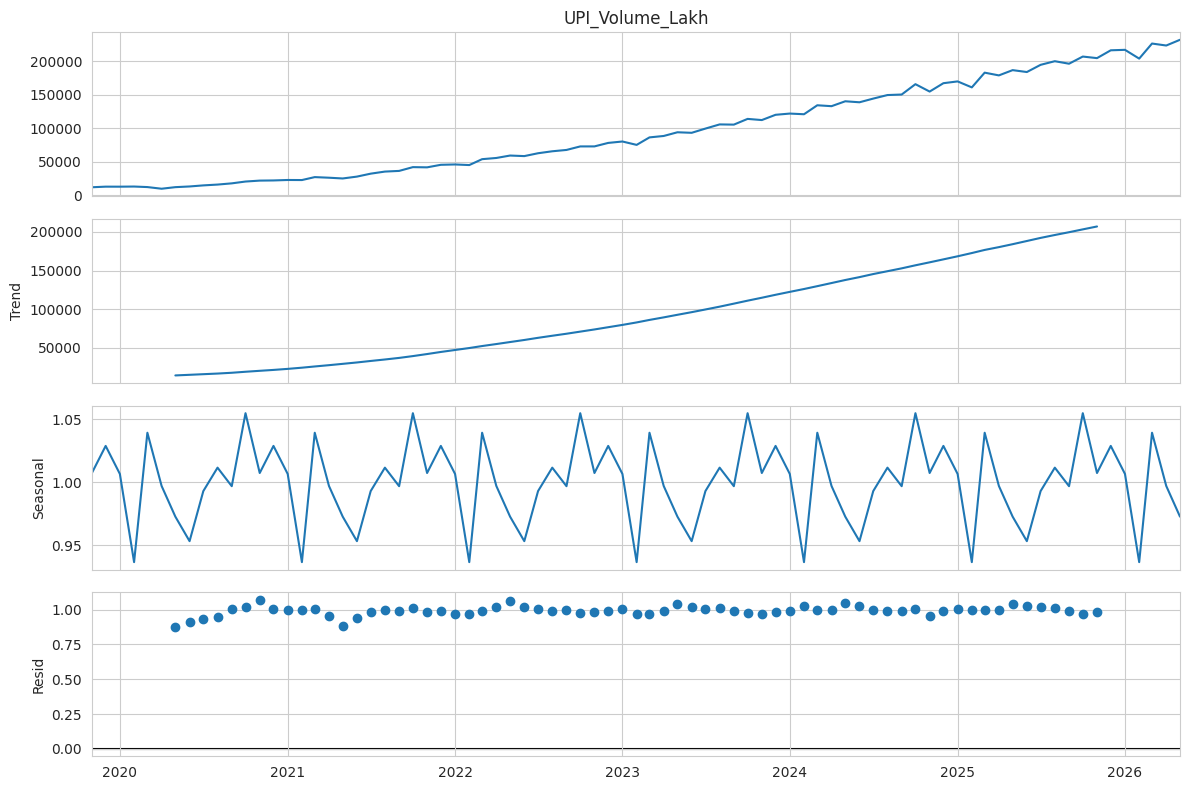

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(upi['UPI_Volume_Lakh'], model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## 07. Rolling Statistics

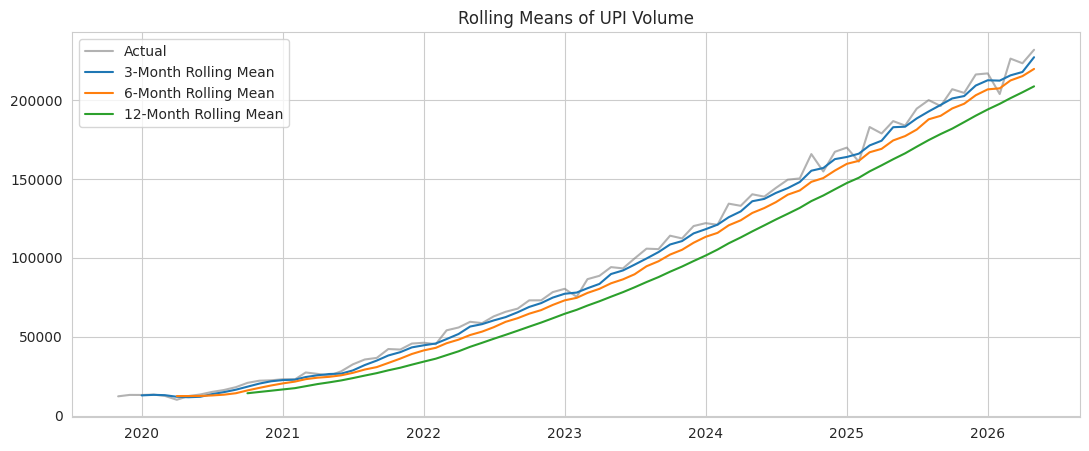

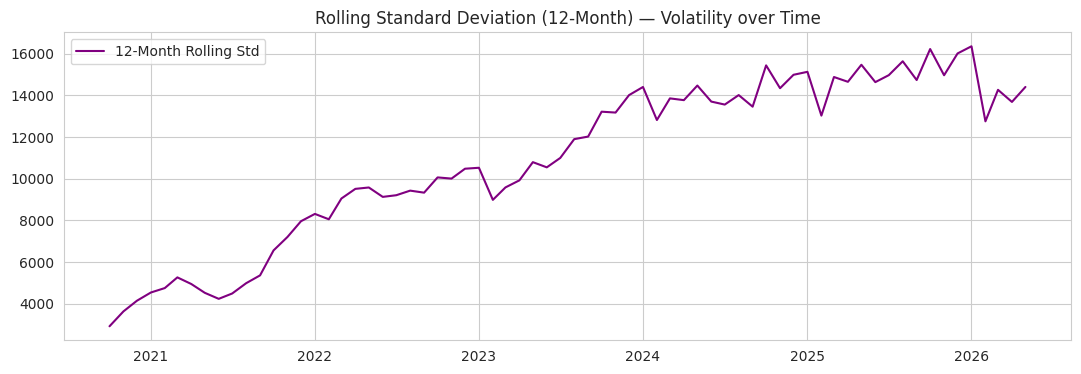

In [13]:
roll = upi[['UPI_Volume_Lakh']].copy()
for w in [3, 6, 12]:
    roll[f'RollMean_{w}'] = roll['UPI_Volume_Lakh'].rolling(w).mean()
    roll[f'RollStd_{w}'] = roll['UPI_Volume_Lakh'].rolling(w).std()

plt.figure(figsize=(13, 5))
plt.plot(roll.index, roll['UPI_Volume_Lakh'], label='Actual', color='grey', alpha=0.6)
plt.plot(roll.index, roll['RollMean_3'], label='3-Month Rolling Mean')
plt.plot(roll.index, roll['RollMean_6'], label='6-Month Rolling Mean')
plt.plot(roll.index, roll['RollMean_12'], label='12-Month Rolling Mean')
plt.title('Rolling Means of UPI Volume')
plt.legend()
plt.show()

plt.figure(figsize=(13, 4))
plt.plot(roll.index, roll['RollStd_12'], label='12-Month Rolling Std', color='purple')
plt.title('Rolling Standard Deviation (12-Month) — Volatility over Time')
plt.legend()
plt.show()

## 08. Stationarity — Augmented Dickey-Fuller (ADF) Test

In [14]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name='series'):
    series = series.dropna()
    result = adfuller(series)
    print(f'--- ADF Test: {name} ---')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    for key, val in result[4].items():
        print(f'  Critical Value ({key}): {val:.4f}')
    conclusion = 'Stationary' if result[1] < 0.05 else 'Non-Stationary'
    print(f'Conclusion    : {conclusion} (alpha=0.05)\n')
    return result[1]

pval_level = adf_report(upi['UPI_Volume_Lakh'], 'UPI Volume (level)')

--- ADF Test: UPI Volume (level) ---
ADF Statistic : -0.1768
p-value       : 0.9412
  Critical Value (1%): -3.5336
  Critical Value (5%): -2.9064
  Critical Value (10%): -2.5907
Conclusion    : Non-Stationary (alpha=0.05)



## 09. Differencing
Since the level series is non-stationary, apply first-order (and seasonal) differencing until the ADF test passes.

In [15]:
upi['Volume_diff1'] = upi['UPI_Volume_Lakh'].diff()
pval_diff1 = adf_report(upi['Volume_diff1'], 'UPI Volume (1st difference)')

upi['Volume_diff1_seasonal12'] = upi['Volume_diff1'].diff(12)
pval_diff1_12 = adf_report(upi['Volume_diff1_seasonal12'], 'UPI Volume (1st diff + seasonal diff-12)')

--- ADF Test: UPI Volume (1st difference) ---
ADF Statistic : -1.7881
p-value       : 0.3864
  Critical Value (1%): -3.5352
  Critical Value (5%): -2.9072
  Critical Value (10%): -2.5911
Conclusion    : Non-Stationary (alpha=0.05)

--- ADF Test: UPI Volume (1st diff + seasonal diff-12) ---
ADF Statistic : -8.8398
p-value       : 0.0000
  Critical Value (1%): -3.5369
  Critical Value (5%): -2.9079
  Critical Value (10%): -2.5915
Conclusion    : Stationary (alpha=0.05)



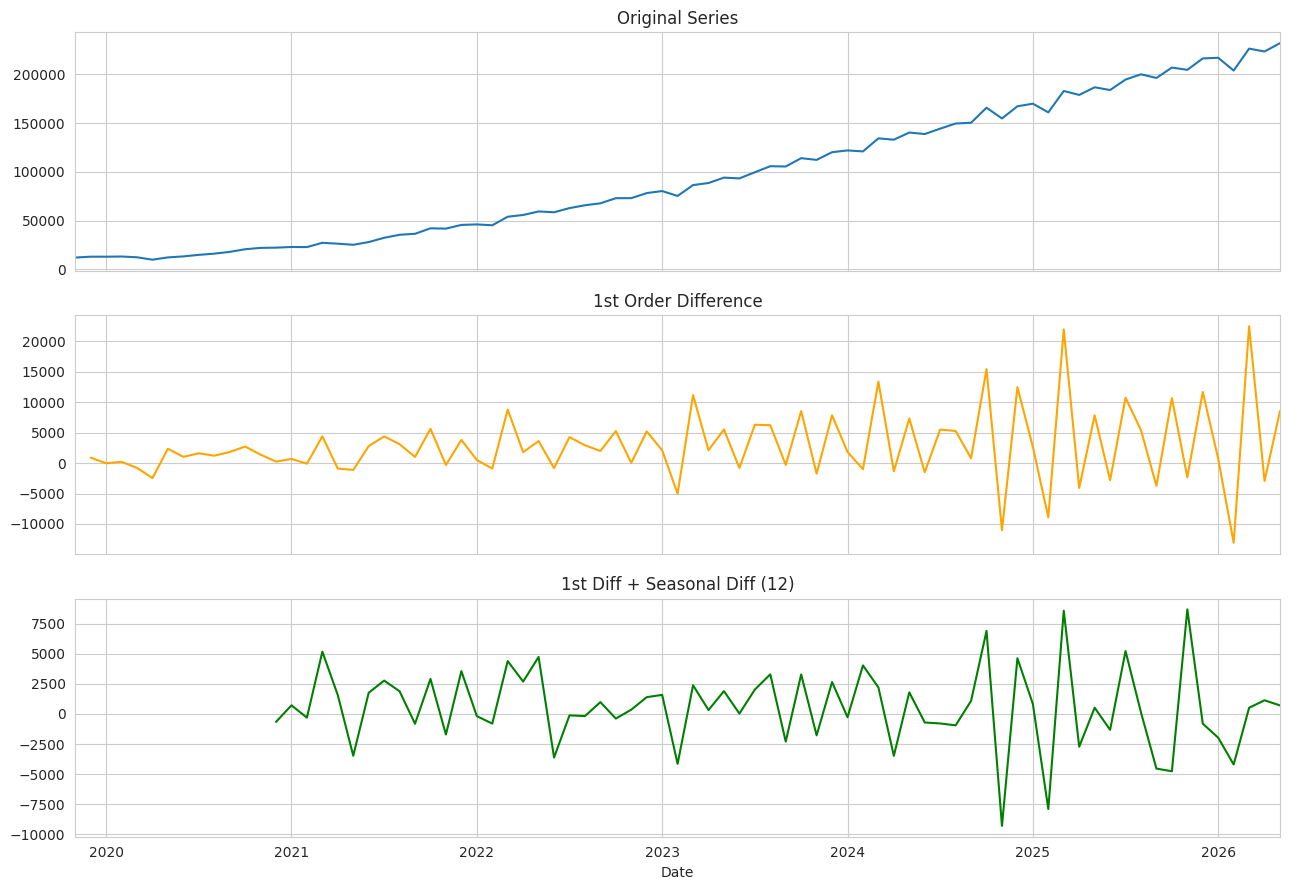

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
upi['UPI_Volume_Lakh'].plot(ax=ax[0], title='Original Series')
upi['Volume_diff1'].plot(ax=ax[1], title='1st Order Difference', color='orange')
upi['Volume_diff1_seasonal12'].plot(ax=ax[2], title='1st Diff + Seasonal Diff (12)', color='green')
plt.tight_layout()
plt.show()

## 10. ACF / PACF Plots
 

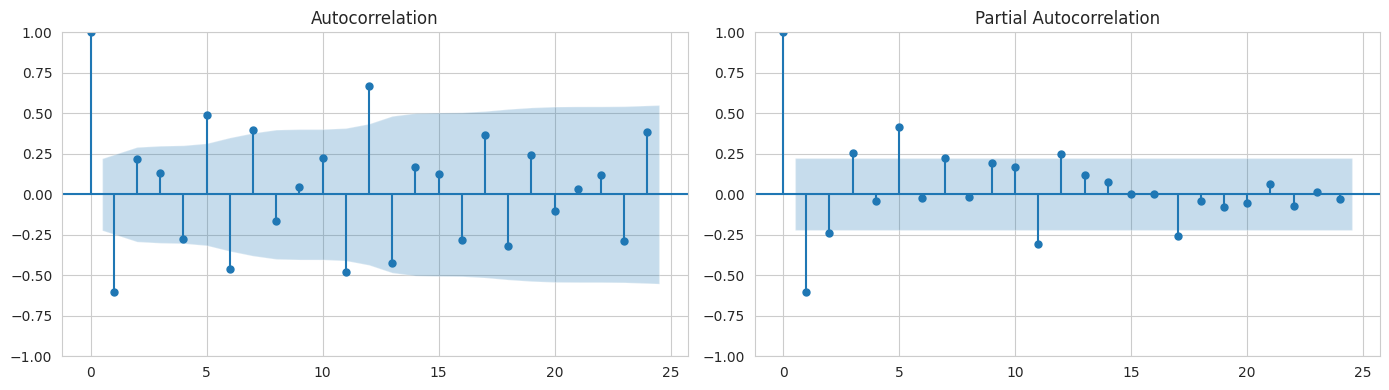

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series_for_acf = upi['Volume_diff1'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_for_acf, ax=ax[0], lags=24)
plot_pacf(series_for_acf, ax=ax[1], lags=24, method='ywm')
plt.tight_layout()
plt.show()

## 11. Train-Test Split
Chronological split — hold out the last 12 months as the test set (no shuffling, since this is time series data).

Train: 2019-11-01 to 2025-05-01  (67 months)
Test : 2025-06-01 to 2026-05-01  (12 months)


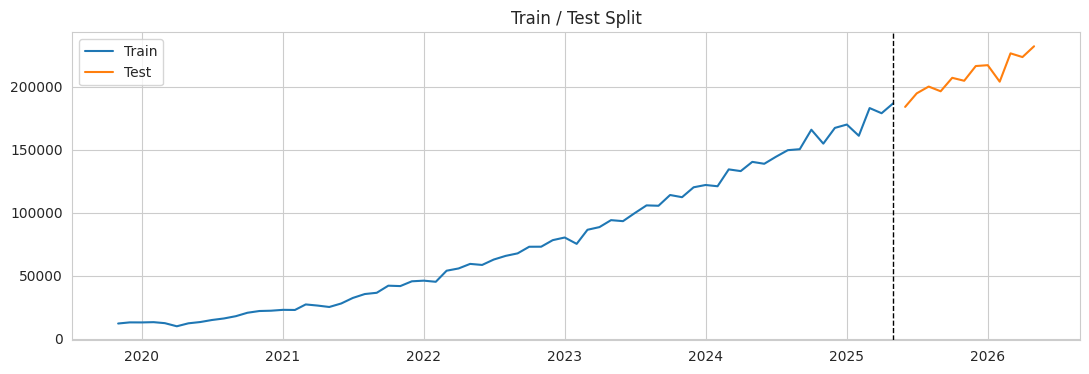

In [18]:
TEST_SIZE = 12
series = upi['UPI_Volume_Lakh'].copy()

train = series.iloc[:-TEST_SIZE]
test = series.iloc[-TEST_SIZE:]

print(f'Train: {train.index.min().date()} to {train.index.max().date()}  ({len(train)} months)')
print(f'Test : {test.index.min().date()} to {test.index.max().date()}  ({len(test)} months)')

plt.figure(figsize=(13, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.axvline(train.index[-1], color='black', linestyle='--', linewidth=1)
plt.title('Train / Test Split')
plt.legend()
plt.show()

## 12. Naive Baseline
Two simple baselines: (a) **Naive** — carry forward the last observed value, and (b) **Seasonal Naive** — repeat the value from 12 months ago.

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'RMSE': rmse(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred)
    }

results = []

# Naive: forecast = last training value repeated
naive_pred = pd.Series([train.iloc[-1]] * len(test), index=test.index)
results.append(evaluate(test, naive_pred, 'Naive (last value)'))

# Seasonal Naive: forecast = value from 12 months earlier
seasonal_naive_pred = series.shift(12).iloc[-TEST_SIZE:]
results.append(evaluate(test, seasonal_naive_pred, 'Seasonal Naive (lag-12)'))

pd.DataFrame(results)

,Model,RMSE,MAE,MAPE_%
0,Naive (last value),26009.713914,22525.095833,10.424207
1,Seasonal Naive (lag-12),46343.918984,46248.045833,22.265828


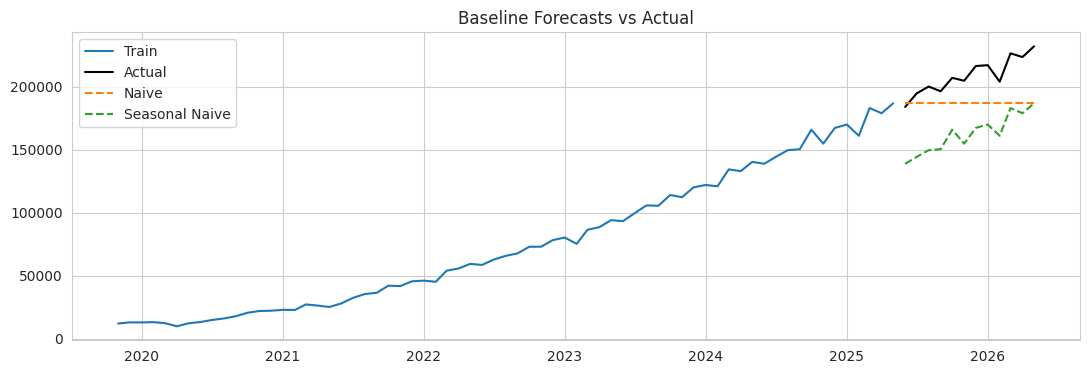

In [20]:
plt.figure(figsize=(13, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index, naive_pred, label='Naive', linestyle='--')
plt.plot(test.index, seasonal_naive_pred, label='Seasonal Naive', linestyle='--')
plt.legend()
plt.title('Baseline Forecasts vs Actual')
plt.show()

## 13. ARIMA
 

In [21]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

p = range(0, 4)
d = [1]
q = range(0, 4)

best_aic = np.inf
best_order = None
best_model_fit = None

for order in itertools.product(p, d, q):
    try:
        m = ARIMA(train, order=order).fit()
        if m.aic < best_aic:
            best_aic = m.aic
            best_order = order
            best_model_fit = m
    except Exception:
        continue

print('Best ARIMA order:', best_order, ' AIC:', round(best_aic, 2))
arima_fit = best_model_fit
print(arima_fit.summary())

Best ARIMA order: (3, 1, 2)  AIC: 1274.43
                               SARIMAX Results                                
Dep. Variable:        UPI_Volume_Lakh   No. Observations:                   67
Model:                 ARIMA(3, 1, 2)   Log Likelihood                -631.217
Date:                Fri, 14 Aug 2026   AIC                           1274.433
Time:                        19:39:37   BIC                           1287.571
Sample:                    11-01-2019   HQIC                          1279.625
                         - 05-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4624      0.090     -5.132      0.000      -0.639      -0.286
ar.L2          0.6822      0.070      9.736      0.000       0.545       0.820
ar.L3     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


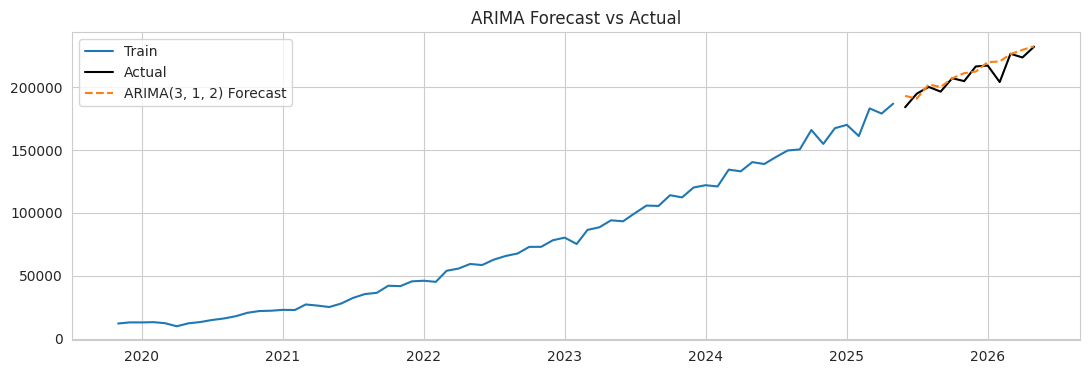

In [22]:
arima_forecast = arima_fit.forecast(steps=TEST_SIZE)
arima_forecast.index = test.index

results.append(evaluate(test, arima_forecast, f'ARIMA{best_order}'))

plt.figure(figsize=(13, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index, arima_forecast, label=f'ARIMA{best_order} Forecast', linestyle='--')
plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.show()

## 14. SARIMA
 

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

seasonal_orders = [(1, 1, 1, 12), (0, 1, 1, 12), (1, 1, 0, 12)]
best_saic = np.inf
best_sorder, best_sseasonal = None, None
best_sarima_fit = None

for order in itertools.product(range(0, 3), [1], range(0, 3)):
    for sorder in seasonal_orders:
        try:
            m = SARIMAX(train, order=order, seasonal_order=sorder,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if m.aic < best_saic:
                best_saic = m.aic
                best_sorder, best_sseasonal = order, sorder
                best_sarima_fit = m
        except Exception:
            continue

print('Best SARIMA order:', best_sorder, 'x', best_sseasonal, ' AIC:', round(best_saic, 2))
sarima_fit = best_sarima_fit

Best SARIMA order: (2, 1, 2) x (0, 1, 1, 12)  AIC: 740.78


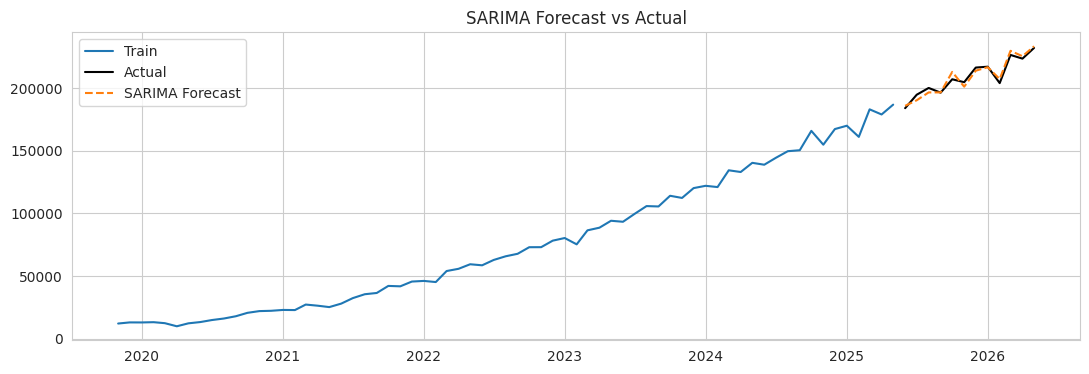

In [24]:
sarima_forecast = sarima_fit.forecast(steps=TEST_SIZE)
sarima_forecast.index = test.index

results.append(evaluate(test, sarima_forecast, f'SARIMA{best_sorder}x{best_sseasonal}'))

plt.figure(figsize=(13, 4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', linestyle='--')
plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.show()

## 15. Lag Feature Engineering
 

In [25]:
ml_df = pd.DataFrame({'y': series})

for lag in [1, 2, 3, 6, 12]:
    ml_df[f'lag_{lag}'] = ml_df['y'].shift(lag)

for w in [3, 6, 12]:
    ml_df[f'rollmean_{w}'] = ml_df['y'].shift(1).rolling(w).mean()
    ml_df[f'rollstd_{w}'] = ml_df['y'].shift(1).rolling(w).std()

ml_df['month'] = ml_df.index.month
ml_df['quarter'] = ml_df.index.quarter
ml_df['month_sin'] = np.sin(2 * np.pi * ml_df['month'] / 12)
ml_df['month_cos'] = np.cos(2 * np.pi * ml_df['month'] / 12)
ml_df['time_idx'] = np.arange(len(ml_df))

ml_df = ml_df.dropna()

feature_cols = [c for c in ml_df.columns if c != 'y']
X, y = ml_df[feature_cols], ml_df['y']

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print('Feature set:', feature_cols)
print('X_train:', X_train.shape, ' X_test:', X_test.shape)
ml_df.head()

Feature set: ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rollmean_3', 'rollstd_3', 'rollmean_6', 'rollstd_6', 'rollmean_12', 'rollstd_12', 'month', 'quarter', 'month_sin', 'month_cos', 'time_idx']
X_train: (55, 16)  X_test: (12, 16)


,y,lag_1,lag_2,lag_3,lag_6,lag_12,rollmean_3,rollstd_3,rollmean_6,rollstd_6,rollmean_12,rollstd_12,month,quarter,month_sin,month_cos,time_idx
Date,,,,,,,,,,,,,,,,,
2020-11-01,22102.28383,20716.19000,18001.67000,16188.28462,12344.97198,12187.70742,18302.048207,2278.848850,15932.327668,3085.141412,14136.417042,2919.027765,11,4,-5.000000e-01,8.660254e-01,12
2020-12-01,22341.58091,22102.28383,20716.19000,18001.67000,13369.30941,13084.01713,20273.381277,2085.861481,17558.546310,3374.083682,14962.631743,3633.104730,12,4,-2.449294e-16,1.000000e+00,13
2021-01-01,23027.28000,22341.58091,22102.28383,20716.19000,14973.54000,13050.19232,21720.018247,877.535831,19053.924893,3125.155196,15734.095392,4144.786142,1,1,5.000000e-01,8.660254e-01,14
2021-02-01,22928.94000,23027.28000,22341.58091,22102.28383,16188.28462,13256.93237,22490.381580,480.115307,20396.214893,2726.188924,16565.519365,4539.361087,2,1,8.660254e-01,5.000000e-01,15
2021-03-01,27316.85000,22928.94000,23027.28000,22341.58091,18001.67000,12468.44550,22765.933637,370.775021,21519.657457,1912.893639,17371.520001,4752.171942,3,1,1.000000e+00,6.123234e-17,16


## 16. Random Forest

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}


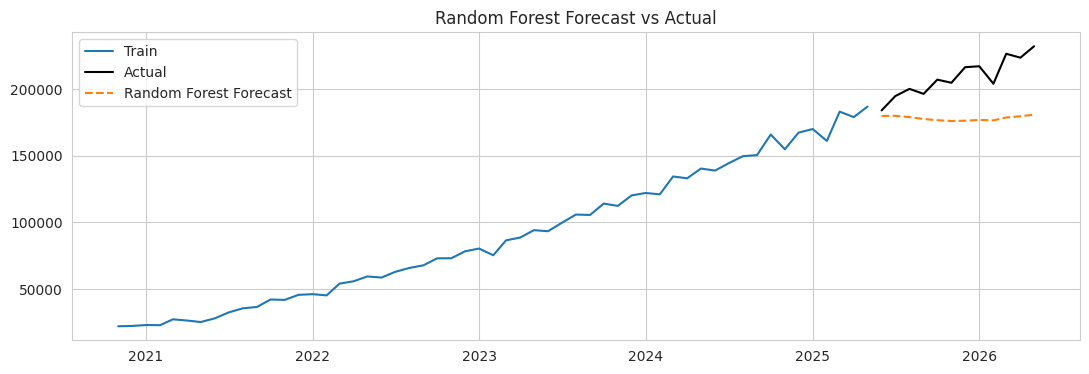

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4)
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid,
                        cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
print('Best RF params:', rf_grid.best_params_)

rf_pred = pd.Series(rf_best.predict(X_test), index=X_test.index)
results.append(evaluate(y_test, rf_pred, 'Random Forest'))

plt.figure(figsize=(13, 4))
plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, rf_pred, label='Random Forest Forecast', linestyle='--')
plt.legend()
plt.title('Random Forest Forecast vs Actual')
plt.show()

## 17. XGBoost

Best XGB params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}


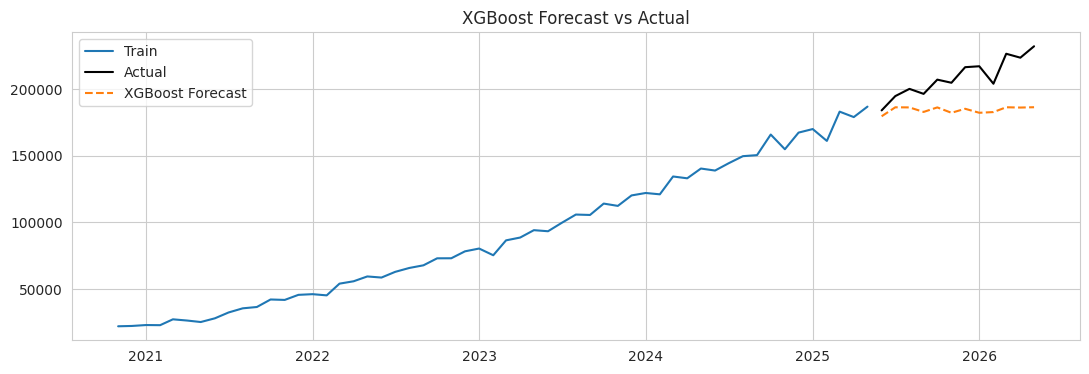

In [27]:
from xgboost import XGBRegressor

xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(XGBRegressor(random_state=42, objective='reg:squarederror'),
                         xgb_param_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
print('Best XGB params:', xgb_grid.best_params_)

xgb_pred = pd.Series(xgb_best.predict(X_test), index=X_test.index)
results.append(evaluate(y_test, xgb_pred, 'XGBoost'))

plt.figure(figsize=(13, 4))
plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, xgb_pred, label='XGBoost Forecast', linestyle='--')
plt.legend()
plt.title('XGBoost Forecast vs Actual')
plt.show()

## 18. Model Evaluation
 

In [28]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,RMSE,MAE,MAPE_%
0,"SARIMA(2, 1, 2)x(0, 1, 1, 12)",3109.109372,2679.485526,1.296339
1,"ARIMA(3, 1, 2)",6343.705043,4570.022151,2.254318
2,Naive (last value),26009.713914,22525.095833,10.424207
3,XGBoost,27601.320829,24507.665729,11.388312
4,Random Forest,33677.386023,30735.670644,14.344625
5,Seasonal Naive (lag-12),46343.918984,46248.045833,22.265828


## 19. Model Comparison

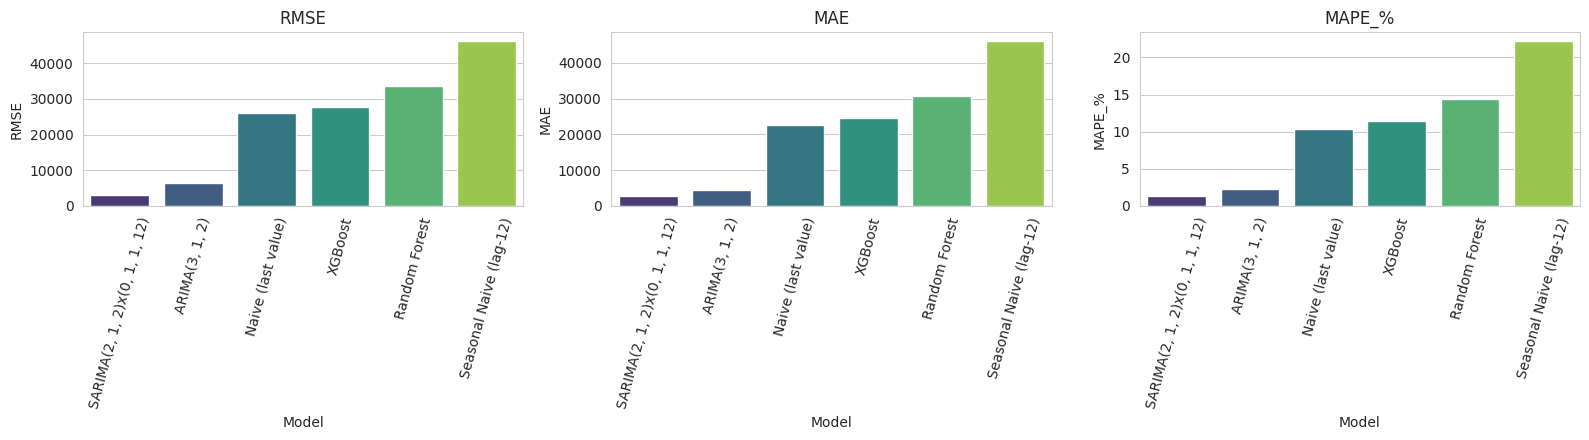

Best performing model on the test set: SARIMA(2, 1, 2)x(0, 1, 1, 12)


In [29]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for i, metric in enumerate(['RMSE', 'MAE', 'MAPE_%']):
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax[i], palette='viridis')
    ax[i].set_title(metric)
    ax[i].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f'Best performing model on the test set: {best_model_name}')

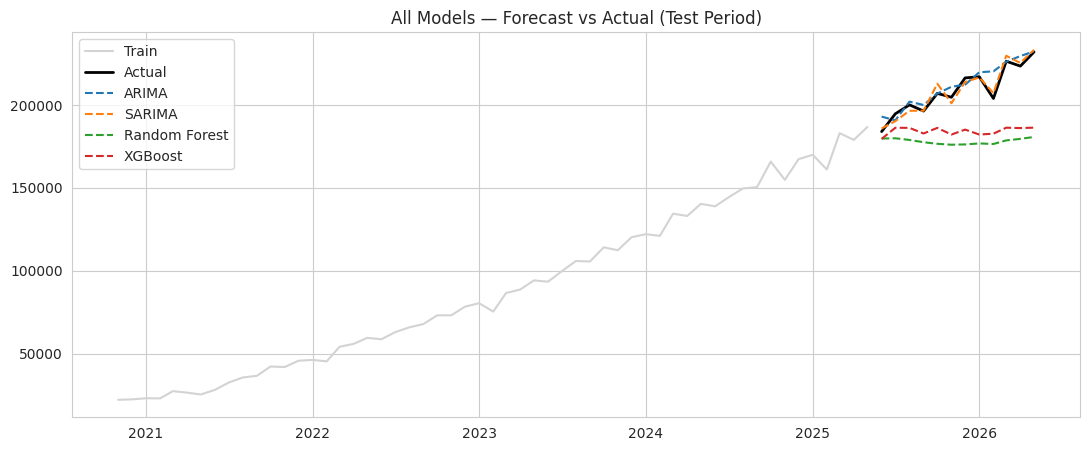

In [30]:
plt.figure(figsize=(13, 5))
plt.plot(y_train.index, y_train, label='Train', color='lightgrey')
plt.plot(y_test.index, y_test, label='Actual', color='black', linewidth=2)
plt.plot(test.index, arima_forecast, label='ARIMA', linestyle='--')
plt.plot(test.index, sarima_forecast, label='SARIMA', linestyle='--')
plt.plot(y_test.index, rf_pred, label='Random Forest', linestyle='--')
plt.plot(y_test.index, xgb_pred, label='XGBoost', linestyle='--')
plt.legend()
plt.title('All Models — Forecast vs Actual (Test Period)')
plt.show()

## 20. Feature Importance

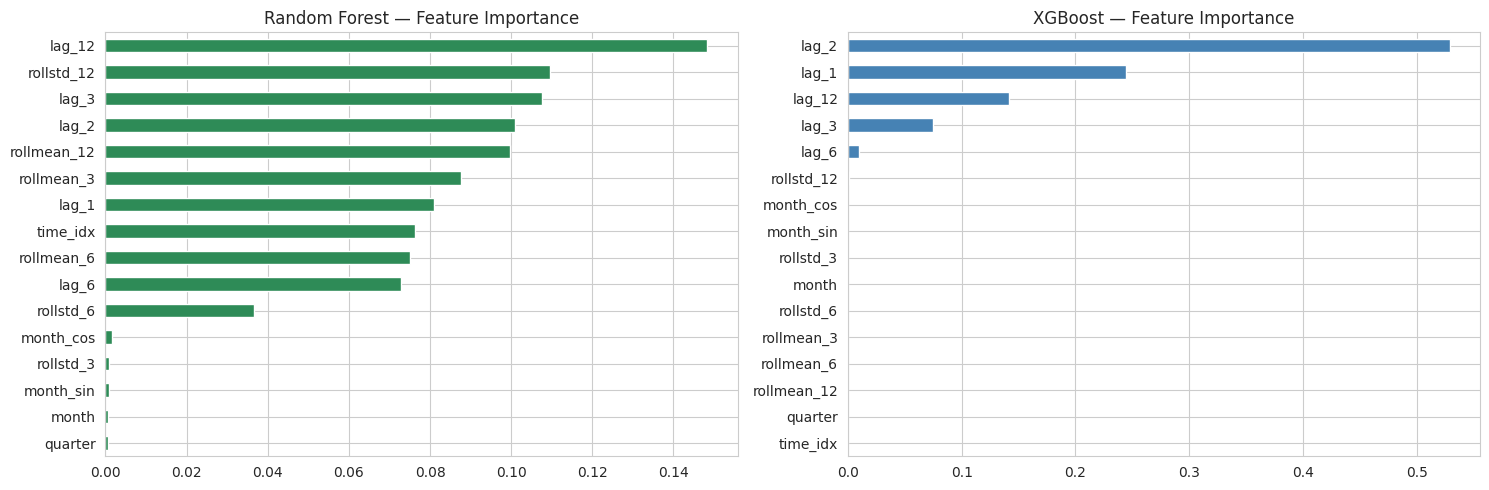

In [31]:
rf_importance = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_best.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
rf_importance.plot(kind='barh', ax=ax[0], color='seagreen')
ax[0].invert_yaxis()
ax[0].set_title('Random Forest — Feature Importance')

xgb_importance.plot(kind='barh', ax=ax[1], color='steelblue')
ax[1].invert_yaxis()
ax[1].set_title('XGBoost — Feature Importance')
plt.tight_layout()
plt.show()

## 21. Future UPI Forecast
Retrain the best-performing model on the **full** dataset and forecast UPI volume for the next 6 months, using a recursive (iterative one-step-ahead) strategy so newly-forecast values feed back in as lag features.

In [32]:
FORECAST_HORIZON = 6
future_dates = pd.date_range(series.index[-1] + pd.offsets.MonthBegin(1), periods=FORECAST_HORIZON, freq='MS')

use_ml = best_model_name in ['Random Forest', 'XGBoost']

if use_ml:
    final_model = rf_best if best_model_name == 'Random Forest' else xgb_best
    # Refit the chosen model type on ALL available labeled rows
    final_model.fit(X, y)

    history = series.copy()
    future_preds = []
    for date in future_dates:
        row = {}
        for lag in [1, 2, 3, 6, 12]:
            row[f'lag_{lag}'] = history.iloc[-lag]
        for w in [3, 6, 12]:
            row[f'rollmean_{w}'] = history.iloc[-w:].mean()
            row[f'rollstd_{w}'] = history.iloc[-w:].std()
        row['month'] = date.month
        row['quarter'] = date.quarter
        row['month_sin'] = np.sin(2 * np.pi * date.month / 12)
        row['month_cos'] = np.cos(2 * np.pi * date.month / 12)
        row['time_idx'] = len(history)

        X_next = pd.DataFrame([row])[feature_cols]
        pred = final_model.predict(X_next)[0]
        future_preds.append(pred)
        history.loc[date] = pred

    future_forecast = pd.Series(future_preds, index=future_dates)
else:
    # Refit SARIMA/ARIMA on full data
    if best_model_name.startswith('SARIMA'):
        final_ts_model = SARIMAX(series, order=best_sorder, seasonal_order=best_sseasonal,
                                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    else:
        final_ts_model = ARIMA(series, order=best_order).fit()
    future_forecast = final_ts_model.forecast(steps=FORECAST_HORIZON)
    future_forecast.index = future_dates

future_forecast

2026-06-01    229897.231251
2026-07-01    239932.595348
2026-08-01    245554.855541
2026-09-01    242824.793919
2026-10-01    254330.152163
2026-11-01    250945.653517
Freq: MS, Name: predicted_mean, dtype: float64

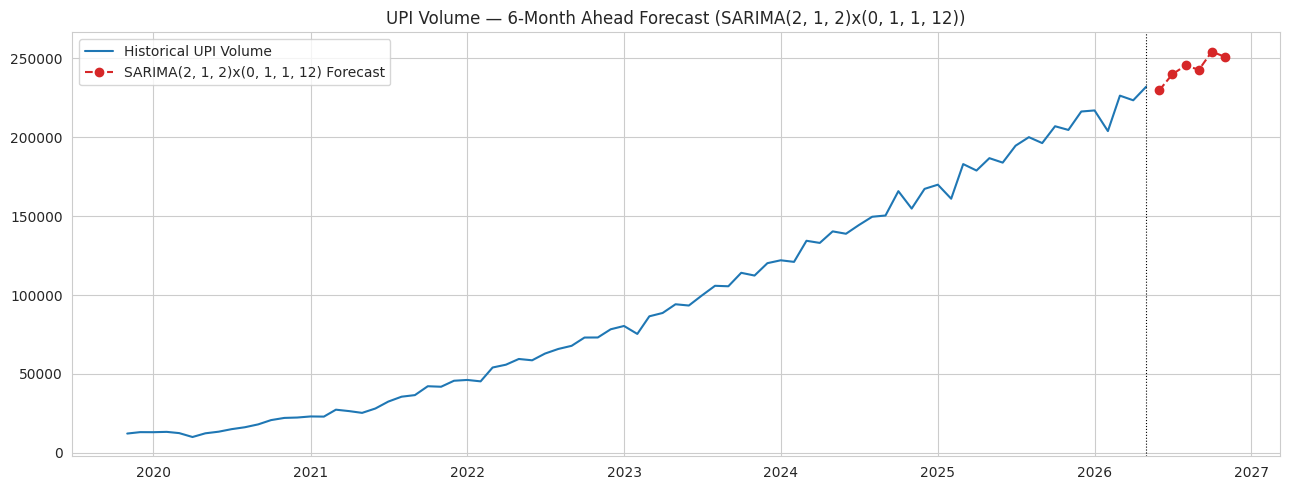

,Forecast_UPI_Volume_Lakh,MoM_Growth_%
2026-06-01,229897.231251,NaN
2026-07-01,239932.595348,4.365152
2026-08-01,245554.855541,2.343267
2026-09-01,242824.793919,-1.111793
2026-10-01,254330.152163,4.738132
2026-11-01,250945.653517,-1.330750


In [33]:
plt.figure(figsize=(13, 5))
plt.plot(series.index, series, label='Historical UPI Volume', color='#1f77b4')
plt.plot(future_forecast.index, future_forecast, label=f'{best_model_name} Forecast', color='#d62728',
         marker='o', linestyle='--')
plt.axvline(series.index[-1], color='black', linewidth=0.8, linestyle=':')
plt.title(f'UPI Volume — {FORECAST_HORIZON}-Month Ahead Forecast ({best_model_name})')
plt.legend()
plt.tight_layout()
plt.show()

forecast_table = future_forecast.to_frame('Forecast_UPI_Volume_Lakh')
forecast_table['MoM_Growth_%'] = forecast_table['Forecast_UPI_Volume_Lakh'].pct_change() * 100
forecast_table

## 22. Business Insights

In [34]:
last_actual = series.iloc[-1]
last_date = series.index[-1]
forecast_end = future_forecast.iloc[-1]
implied_growth = (forecast_end / last_actual - 1) * 100
avg_yoy = upi['YoY_Growth_%'].mean()
best_metrics = results_df.iloc[0]

print('KEY BUSINESS INSIGHTS')
print('=' * 60)
print(f"1. UPI volume grew from {series.iloc[0]:,.0f} lakh txns ({series.index[0].date()}) "
      f"to {last_actual:,.0f} lakh txns ({last_date.date()}) — a "
      f"{(last_actual/series.iloc[0]-1)*100:,.0f}% increase over the sample period.")
print(f"2. Average year-over-year growth rate: {avg_yoy:,.1f}%, reflecting sustained, "
      f"structural adoption growth (not just a one-off pandemic-era spike).")
print(f"3. The series shows clear 12-month seasonality (confirmed via decomposition + "
      f"boxplot-by-month) — volumes typically dip in Feb (shorter month) and build through "
      f"the December festive/quarter-end period.")
print(f"4. Best forecasting model: {best_metrics['Model']} "
      f"(RMSE={best_metrics['RMSE']:,.0f}, MAPE={best_metrics['MAPE_%']:.2f}%), "
      f"outperforming both naive baselines — meaningful, learnable signal beyond pure trend.")
print(f"5. Projected volume in {future_forecast.index[-1].strftime('%b-%Y')}: "
      f"{forecast_end:,.0f} lakh transactions, an implied {implied_growth:,.1f}% change "
      f"from the last observed month ({last_date.strftime('%b-%Y')}).")
print("6. Lag-1 and lag-12 volumes plus short-term rolling means dominate ML feature "
      "importance — recent momentum and last year's same-month level are the strongest "
      "predictors, reinforcing the seasonality finding.")
print("=" * 60)

KEY BUSINESS INSIGHTS
1. UPI volume grew from 12,188 lakh txns (2019-11-01) to 232,019 lakh txns (2026-05-01) — a 1,804% increase over the sample period.
2. Average year-over-year growth rate: 65.3%, reflecting sustained, structural adoption growth (not just a one-off pandemic-era spike).
3. The series shows clear 12-month seasonality (confirmed via decomposition + boxplot-by-month) — volumes typically dip in Feb (shorter month) and build through the December festive/quarter-end period.
4. Best forecasting model: SARIMA(2, 1, 2)x(0, 1, 1, 12) (RMSE=3,109, MAPE=1.30%), outperforming both naive baselines — meaningful, learnable signal beyond pure trend.
5. Projected volume in Nov-2026: 250,946 lakh transactions, an implied 8.2% change from the last observed month (May-2026).
6. Lag-1 and lag-12 volumes plus short-term rolling means dominate ML feature importance — recent momentum and last year's same-month level are the strongest predictors, reinforcing the seasonality finding.


### Recommendations
- **Capacity planning:** Scale UPI switch/NPCI infrastructure ahead of seasonal peaks (festive months, fiscal year-end) identified in the seasonality analysis.
- **Monitoring:** Track MAPE of the deployed model monthly and retrain when error drifts beyond the historical baseline, since digital-payments adoption trends can shift with policy changes (e.g., new UPI features, fee/regulatory changes).
- **Cross-instrument view:** Because UPI volume is highly correlated with Mobile/Internet Payments volume, a combined leading-indicator dashboard could give earlier warning of regime shifts than UPI data alone.
- **Extend the target:** Repeat this pipeline for `UPI_Value_RsCr` and `UPI_Avg_Ticket_Size_Rs` to separate *transaction count* growth from *transaction size* growth — they may have different drivers and forecasts.
